## 0 安装

```bash
# git clone https://github.com/myang682/stockportfoliotoolkit
cd stockportfoliotoolkit
pip install -e .
```

In [1]:
import stockportfoliotoolkit as spt

spt.__version__, spt.__all__

('0.1.0',
 ['InputProcessor',
  'PortfolioEngine',
  'Analyzer',
  'Visualizer',
  'run_pipeline',
  'PipelineResult',
  'InputConfig',
  'EngineConfig',
  'AnalyzerConfig',
  'VisualizerConfig',
  'PipelineConfig',
  'InputBundle',
  'EngineResult',
  'AnalysisResult',
  'to_legacy_wide',
  '__version__'])

## 1 数据

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.feather as feather

PRICES = "/mnt/df7c3e41-975f-4e19-950b-bf2143e9dd82/MingzhiYang/stock_rag_cache/processed/processed_stock_data.feather"

feather.read_table(PRICES, memory_map=True).schema.names

['date',
 'id',
 'siccd',
 'close',
 'cap',
 'ret',
 'vol',
 'low',
 'high',
 'open',
 'shares',
 'market_cap',
 'label',
 'log_ret',
 'cum_log_ret',
 'ewma_vol',
 'ret_week',
 'ret_month',
 'ret_quarter',
 'ret_year',
 'ret_5d',
 'ret_20d',
 'ret_60d',
 'ret_250d',
 'ma_5',
 'ma_20',
 'ma_60',
 'ma_250',
 'log_open',
 'log_high',
 'log_low',
 'log_close',
 'log_vol',
 'log_ret_x100',
 'trend_5',
 'realized_vol_5',
 'trend_20',
 'realized_vol_20',
 'trend_60',
 'realized_vol_60',
 'trend_250',
 'realized_vol_250',
 '__index_level_0__']

In [3]:
feather.read_table(
    PRICES, columns=["date", "id", "close", "cap", "cum_log_ret"], memory_map=True
).slice(0, 5).to_pandas()

,date,id,close,cap,cum_log_ret
0,1992-01-02,10001,14.500,15587.50,0.0000
1,1992-01-03,10001,14.500,15587.50,0.0000
2,1992-01-06,10001,14.500,15587.50,0.0000
3,1992-01-07,10001,14.500,15587.50,0.0000
4,1992-01-08,10001,15.125,16259.38,0.0422


## 2 alpha

本包只消费 alpha，不生成信号。MOM = `close[t-21] / close[t-252] - 1`。

In [4]:
%%time
panel = feather.read_table(
    PRICES, columns=["date", "id", "close", "cum_log_ret"], memory_map=True
).to_pandas().sort_values(["id", "date"], kind="stable", ignore_index=True)

g = panel.groupby("id", sort=False)
alpha = g["close"].shift(21) / g["close"].shift(252) - 1.0
fwd_ret = np.exp(g["cum_log_ret"].shift(-5) - panel["cum_log_ret"]) - 1.0

days = pd.DatetimeIndex(np.unique(panel["date"].to_numpy()))
anchors = set(days[days >= "2021-01-04"][::5])

signal = (
    panel[["date", "id"]]
    .assign(alpha=alpha.to_numpy(), fwd_ret=fwd_ret.to_numpy())
    .query("date in @anchors")
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["alpha"])
    .sort_values(["date", "id"], kind="stable", ignore_index=True)
)
del panel, alpha, fwd_ret, g
signal.head()

CPU times: user 9.59 s, sys: 5.24 s, total: 14.8 s
Wall time: 12.1 s


,date,id,alpha,fwd_ret
0,2021-01-04,10026,-0.231237,0.005321
1,2021-01-04,10028,2.021429,0.120623
2,2021-01-04,10032,-0.020332,0.081269
3,2021-01-04,10044,-0.523864,0.102439
4,2021-01-04,10051,-0.141912,0.051826


In [5]:
WORK = Path("/mnt/df7c3e41-975f-4e19-950b-bf2143e9dd82/MingzhiYang/portfolio_tool_cache/notebook_demo")
WORK.mkdir(parents=True, exist_ok=True)
SIGNAL_PATH = WORK / "signal_mom.feather"
signal.to_feather(SIGNAL_PATH)

len(signal), signal["date"].nunique(), signal["id"].nunique()

(1211662, 251, 6786)

## 3 四个模块分别配置

每个模块一份 JSON。包里没有任何硬编码路径，`column_map` 负责把你的列名接到契约列上。

In [ ]:
import json

CONFIGS = WORK / "configs"
CONFIGS.mkdir(exist_ok=True)
OUT = Path.cwd() / "outputs" / "notebook_mom"

configs = {
    "input.json": {
        "vars": {"SIG": str(WORK)},
        "prices": {
            "path": PRICES,
            "column_map": {"date": "date", "id": "id", "close": "close", "cap": "cap"},
            "restrict_to_signal_assets": True,
        },
        "signals": [
            {
                "name": "MOM",
                "path": "${SIG}/signal_mom.feather",
                "column_map": {"date": "date", "id": "id", "alpha": "alpha", "fwd_ret": "fwd_ret"},
            }
        ],
        "calendar": {"first_rebalance": "2021-01-04", "rebalance_freq": 5},
    },
    "engine.json": {
        "n_buckets": 10,
        "min_names": 20,
        "holding_days": 5,
        "weights": ["ew", "vw", "logvw"],
        "forward_return": {"source": "signals"},
    },
    "analyzer.json": {
        "metrics": ["ann_ret", "ann_vol", "sharpe", "max_drawdown", "total_equity", "hit_rate"],
    },
    "visualizer.json": {
        "output_dir": str(OUT),
        "charts": [
            {"name": "long_short", "buckets": ["H-L"], "show_baseline": True},
            {
                "name": "decile_spread",
                "buckets": [str(i) for i in range(10)] + ["H-L"],
                "color_mode": "gradient",
                "legend_ncol": 2,
            },
        ],
        "tables": [
            {"name": "metrics_by_bucket", "type": "summary"},
            {"name": "ic_by_period", "type": "ic"},
        ],
    },
}
for name, payload in configs.items():
    (CONFIGS / name).write_text(json.dumps(payload, indent=2), encoding="utf-8")

sorted(p.name for p in CONFIGS.iterdir())

['analyzer.json', 'engine.json', 'input.json', 'visualizer.json']

## 4 跑

In [7]:
%%time
from stockportfoliotoolkit import run_pipeline

result = run_pipeline(CONFIGS)

CPU times: user 14.2 s, sys: 5.61 s, total: 19.8 s
Wall time: 17.4 s


## 5 结果

In [8]:
print(json.dumps(result.bundle.meta, indent=2, ensure_ascii=False))

{
  "signals": {
    "MOM": {
      "rows": 1211662,
      "assets": 6786,
      "first": "2021-01-04",
      "last": "2025-12-24",
      "rows_on_calendar": 1211662,
      "alpha_na_rate": 0.0
    }
  },
  "prices": {
    "rows": 6574703,
    "assets": 6786,
    "first": "2021-01-04",
    "last": "2025-12-31"
  },
  "references": [],
  "calendar": {
    "periods": 251,
    "first": "2021-01-04",
    "last": "2025-12-24",
    "rebalance_freq": 5,
    "native_stride": 5,
    "applied_stride": 1
  }
}


In [9]:
result.engine.returns.head()

,date,signal_model,bucket,weight,ret,count
0,2021-01-04,MOM,0,EW,0.111624,445
1,2021-01-11,MOM,0,EW,0.062962,446
2,2021-01-19,MOM,0,EW,0.019532,446
3,2021-01-26,MOM,0,EW,0.047095,450
4,2021-02-02,MOM,0,EW,0.092982,435


In [10]:
summary = result.analysis.summary
summary[summary["bucket"] == "H-L"].round(4)

,signal_model,bucket,weight,n_periods,ann_ret,ann_vol,sharpe,max_drawdown,total_equity,hit_rate,turnover,ic_mean
10,MOM,H-L,EW,250,0.0923,0.2153,0.4288,-0.4202,1.4060,0.572,0.2648,0.0291
21,MOM,H-L,LOGVW,250,0.1117,0.2208,0.5059,-0.3448,1.5386,0.568,0.2648,0.0291
32,MOM,H-L,VW,250,0.1714,0.3024,0.5670,-0.3767,1.8676,0.528,0.2648,0.0291


In [11]:
summary[summary["weight"] == "EW"].round(4)

,signal_model,bucket,weight,n_periods,ann_ret,ann_vol,sharpe,max_drawdown,total_equity,hit_rate,turnover,ic_mean
0,MOM,0,EW,250,-0.0772,0.3308,-0.2334,-0.8023,0.5195,0.508,0.2848,0.0291
1,MOM,1,EW,250,0.0337,0.2599,0.1296,-0.5407,0.9989,0.520,0.4345,0.0291
2,MOM,2,EW,250,0.0809,0.2074,0.3900,-0.3384,1.3419,0.548,0.5317,0.0291
3,MOM,3,EW,250,0.0938,0.1723,0.5441,-0.2618,1.4782,0.544,0.5942,0.0291
4,MOM,4,EW,250,0.0903,0.1502,0.6011,-0.2471,1.4790,0.556,0.6254,0.0291
5,MOM,5,EW,250,0.1006,0.1512,0.6654,-0.2133,1.5551,0.580,0.6342,0.0291
6,MOM,6,EW,250,0.0990,0.1584,0.6253,-0.1989,1.5347,0.600,0.6136,0.0291
7,MOM,7,EW,250,0.1164,0.1718,0.6775,-0.2016,1.6545,0.576,0.5641,0.0291
8,MOM,8,EW,250,0.1145,0.1996,0.5738,-0.3021,1.5974,0.588,0.4516,0.0291
9,MOM,9,EW,250,0.0151,0.2652,0.0570,-0.5282,0.9045,0.524,0.2545,0.0291


In [12]:
result.analysis.ic.head()

,signal_model,date,ic,count
0,MOM,2021-01-04,0.008399,4446
1,MOM,2021-01-11,-0.034371,4452
2,MOM,2021-01-19,0.059905,4452
3,MOM,2021-01-26,0.060289,4496
4,MOM,2021-02-02,-0.000085,4349


In [13]:
result.analysis.turnover.dropna().head()

,signal_model,bucket,date,turnover
11,MOM,2,2021-01-11,0.542623
12,MOM,9,2021-01-11,0.279923
13,MOM,5,2021-01-11,0.566828
14,MOM,0,2021-01-11,0.286538
15,MOM,6,2021-01-11,0.533003


In [14]:
[p.name for p in result.outputs]

['long_short_ew.png',
 'long_short_logvw.png',
 'long_short_vw.png',
 'decile_spread_ew.png',
 'decile_spread_logvw.png',
 'decile_spread_vw.png',
 'metrics_by_bucket.csv',
 'ic_by_period.csv',
 'summary_metrics.csv',
 'curves.feather']

## 6 图

long_short_ew.png


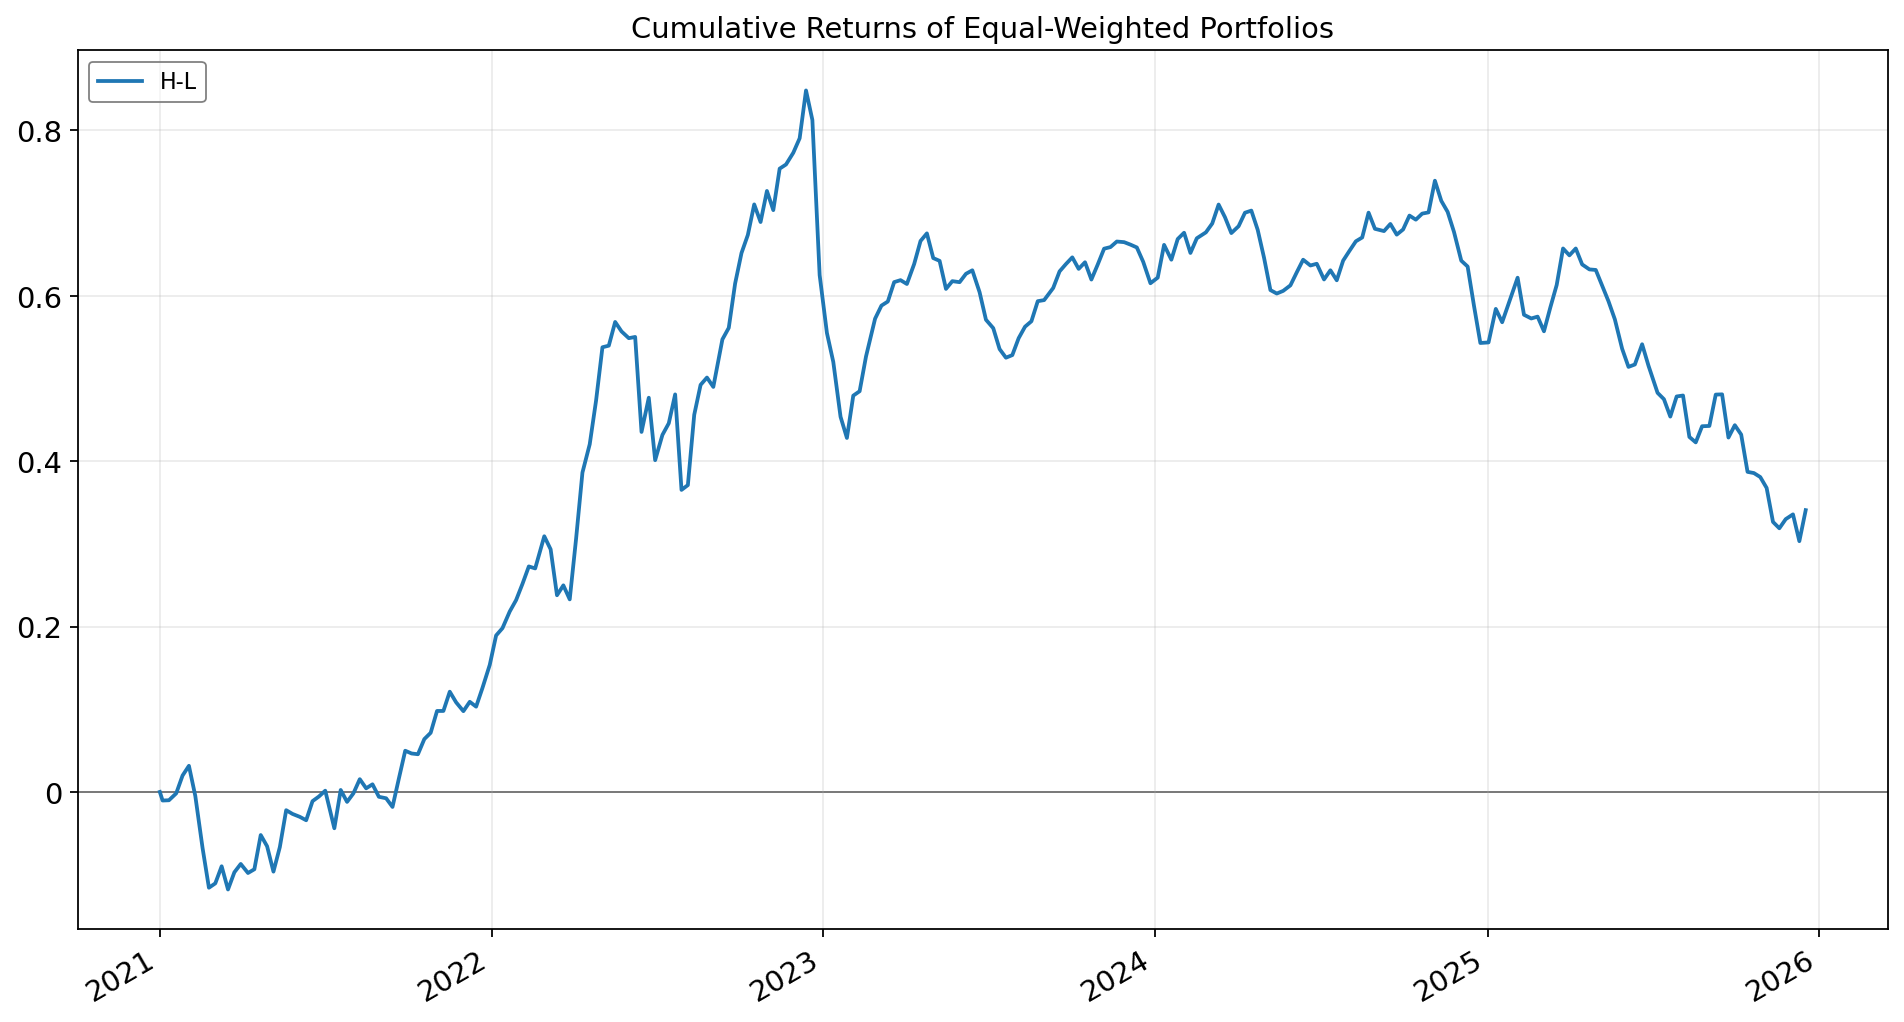

long_short_logvw.png


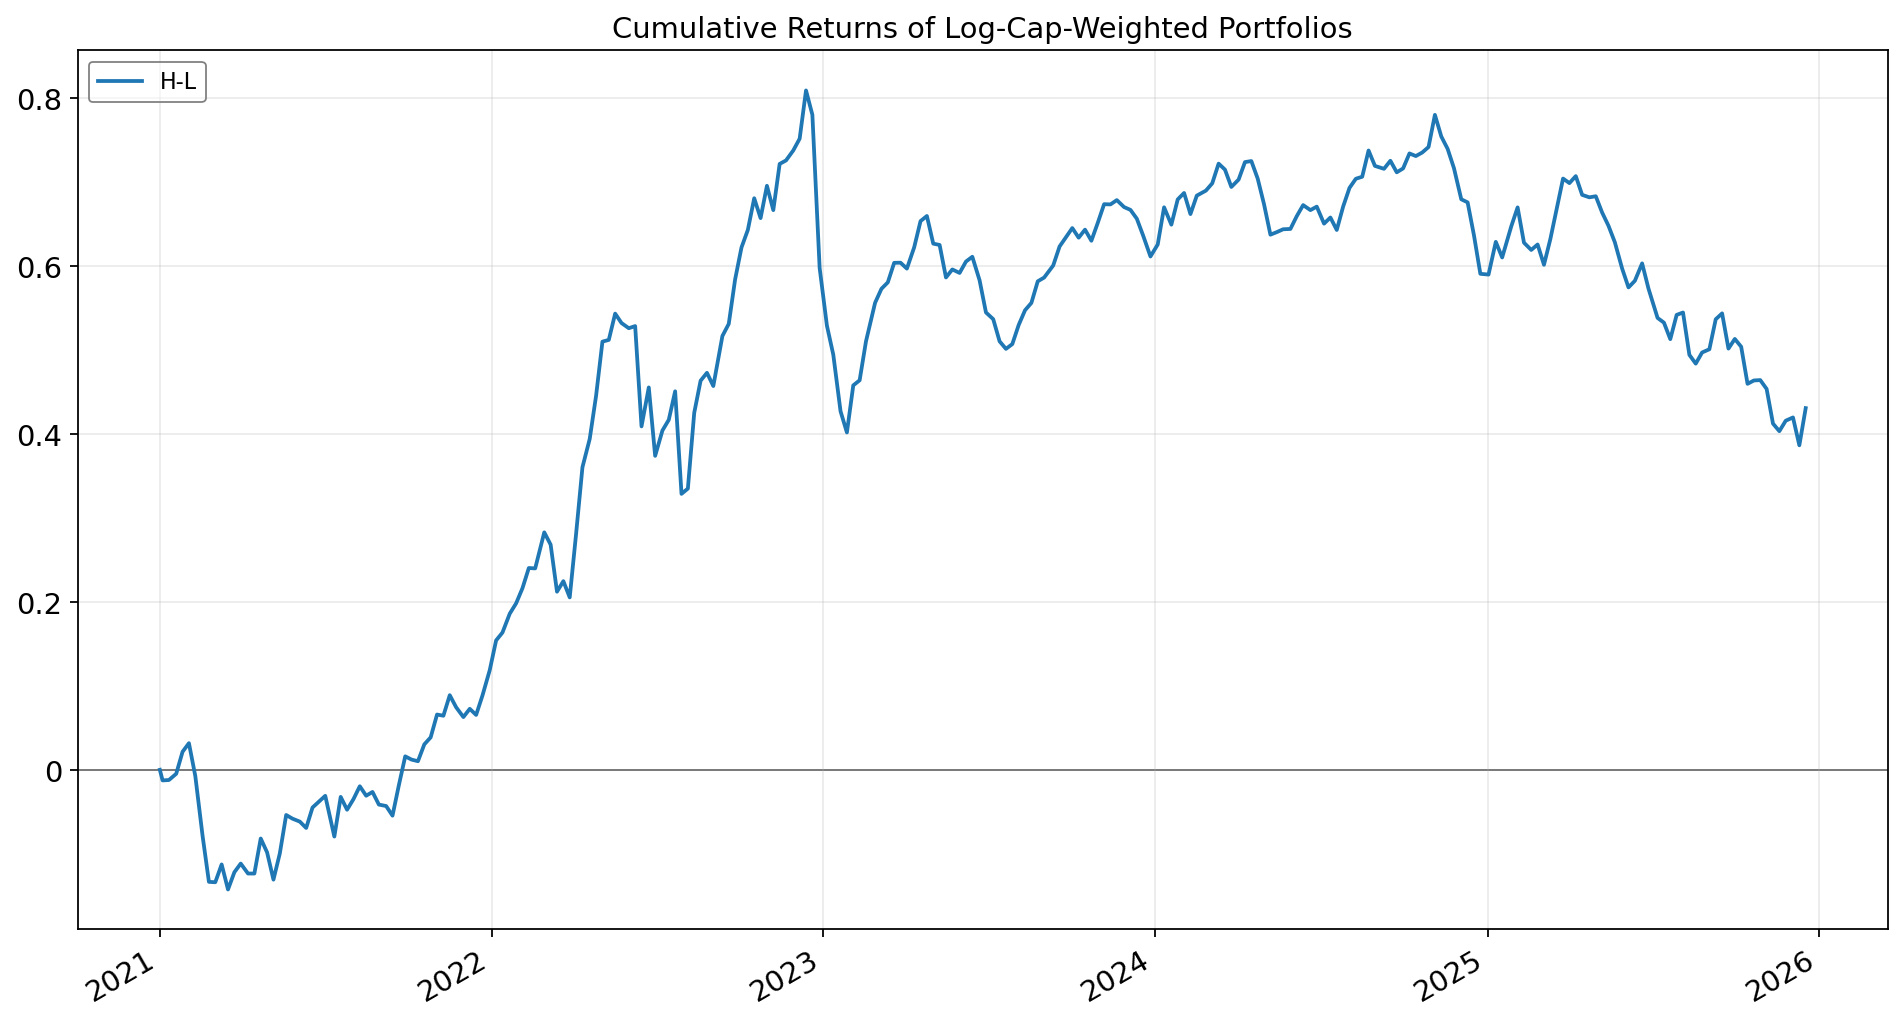

long_short_vw.png


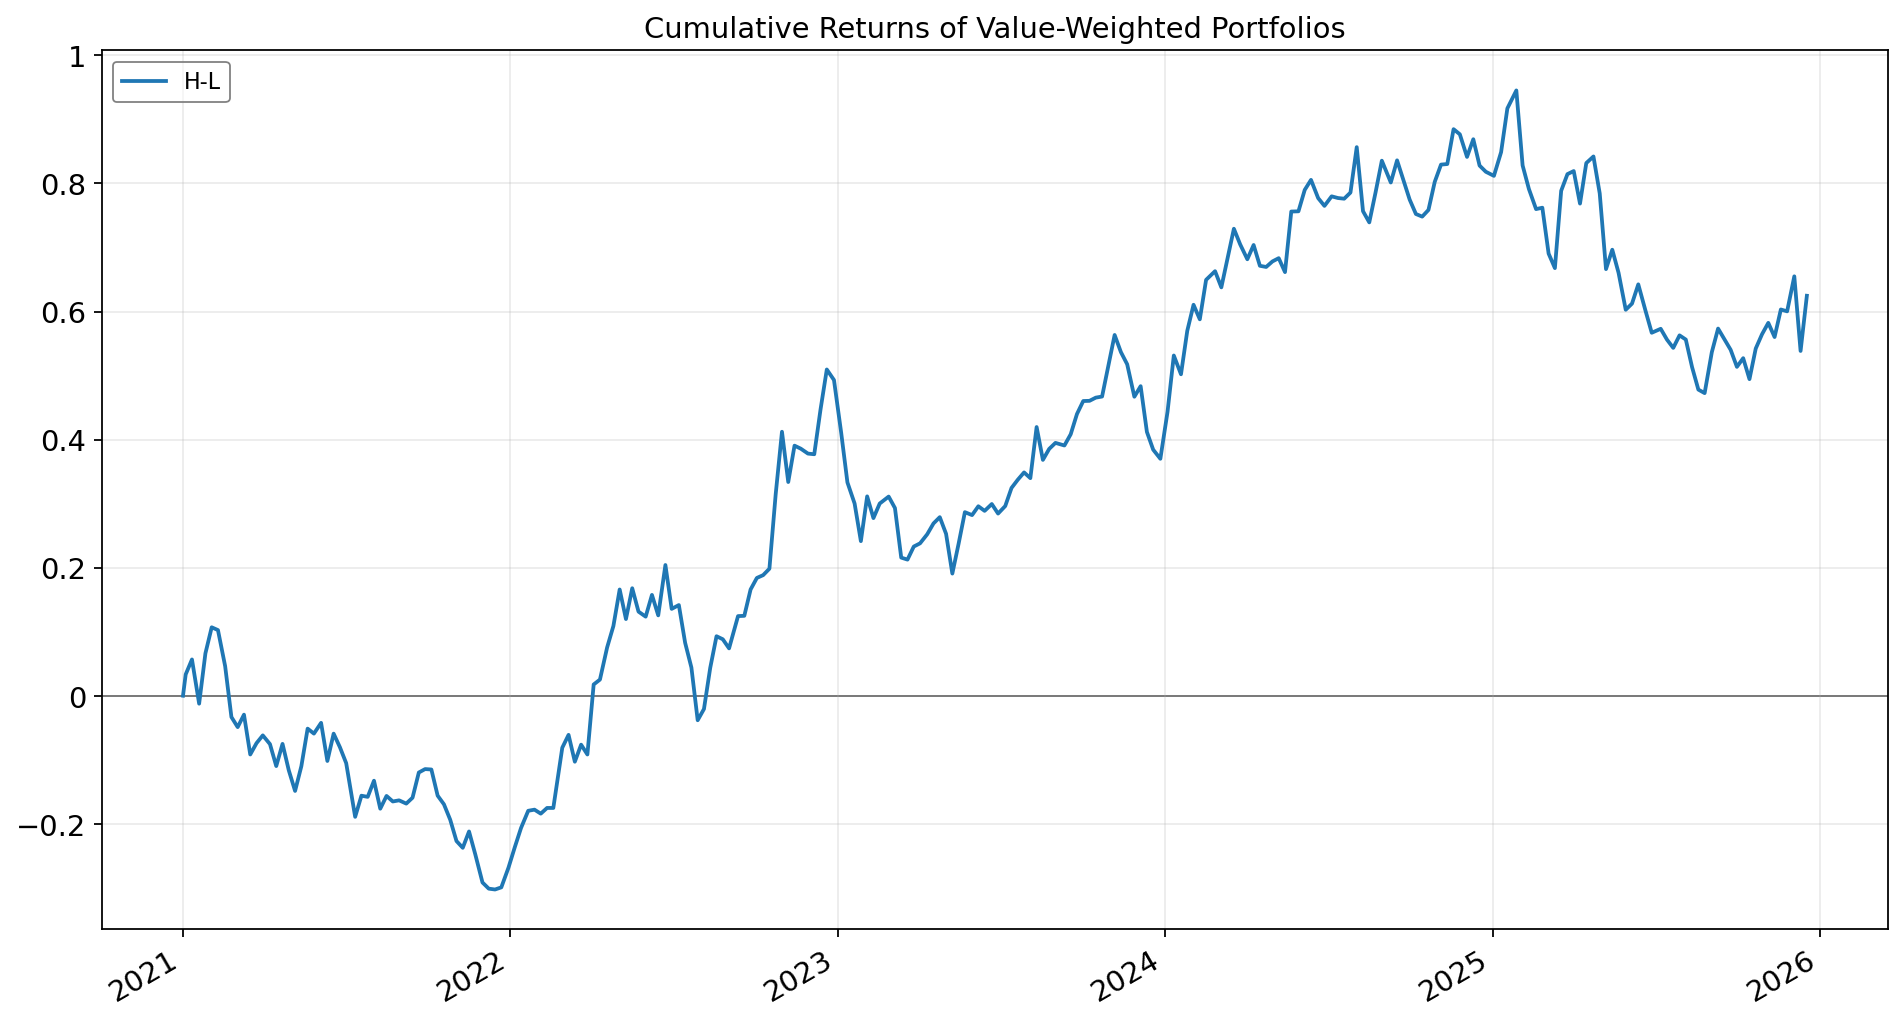

decile_spread_ew.png


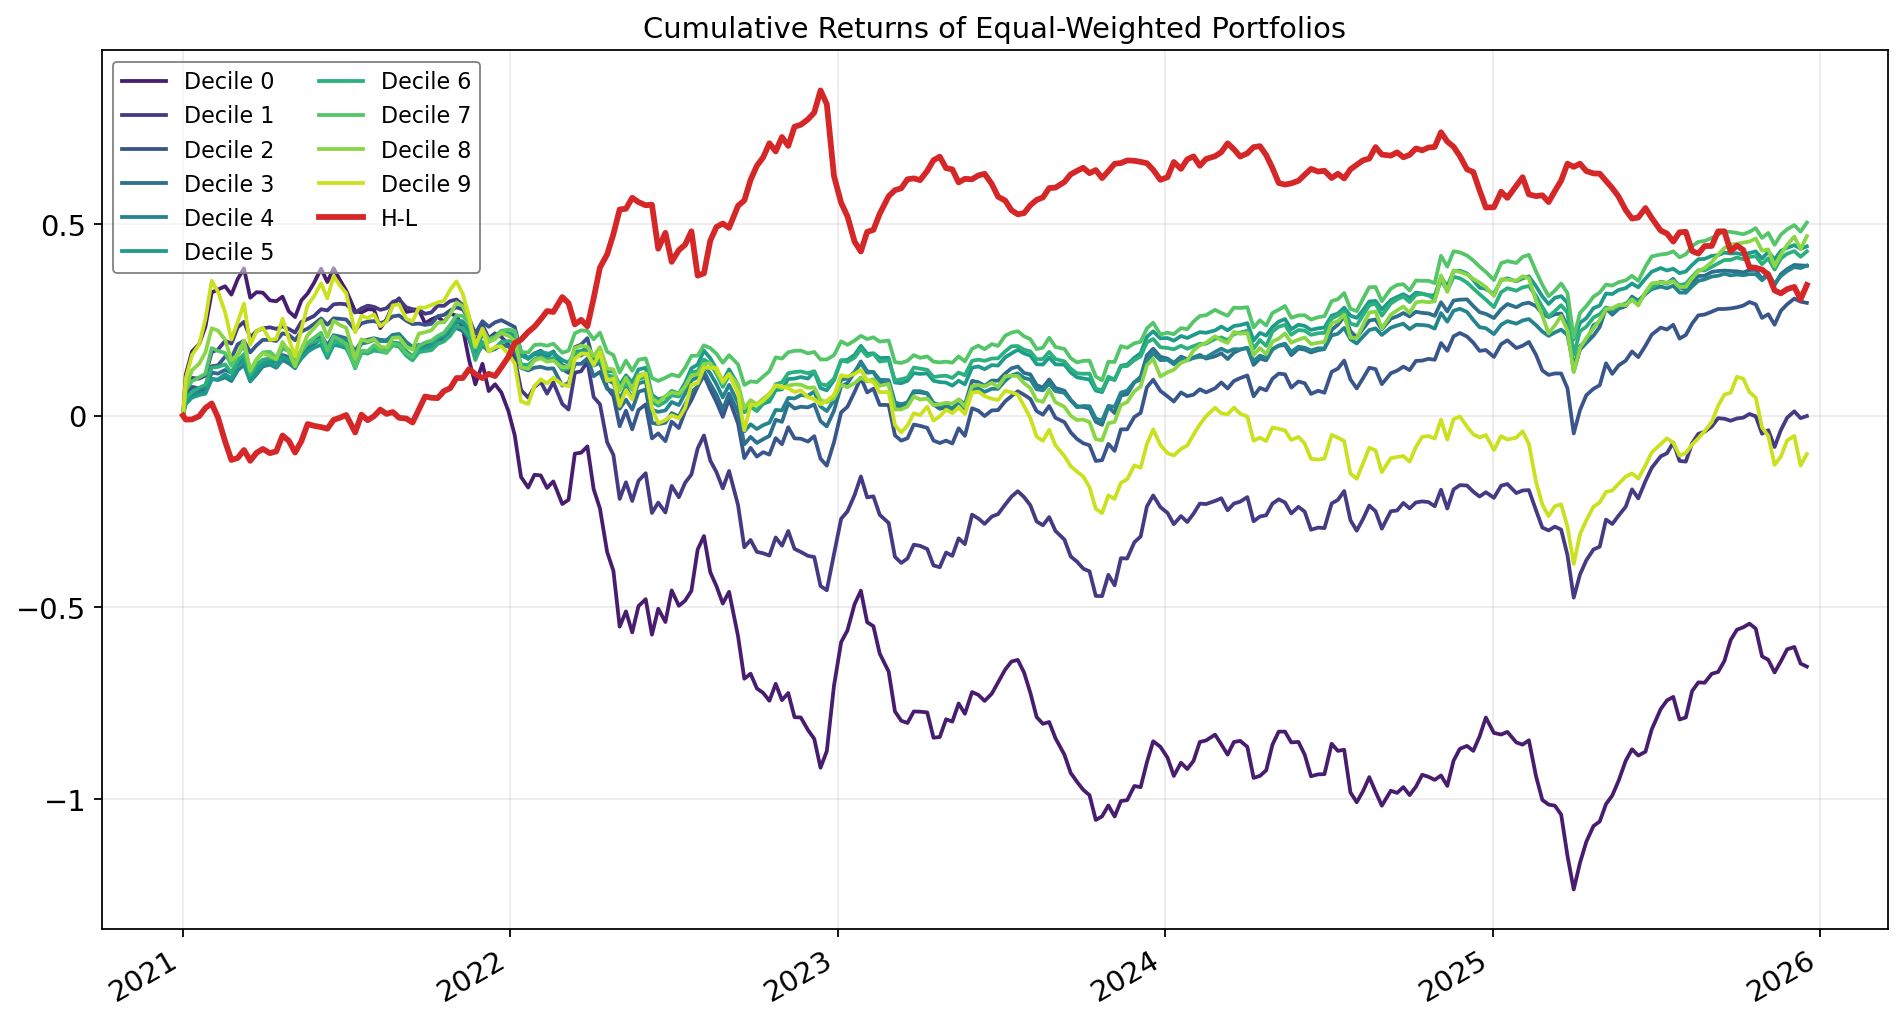

decile_spread_logvw.png


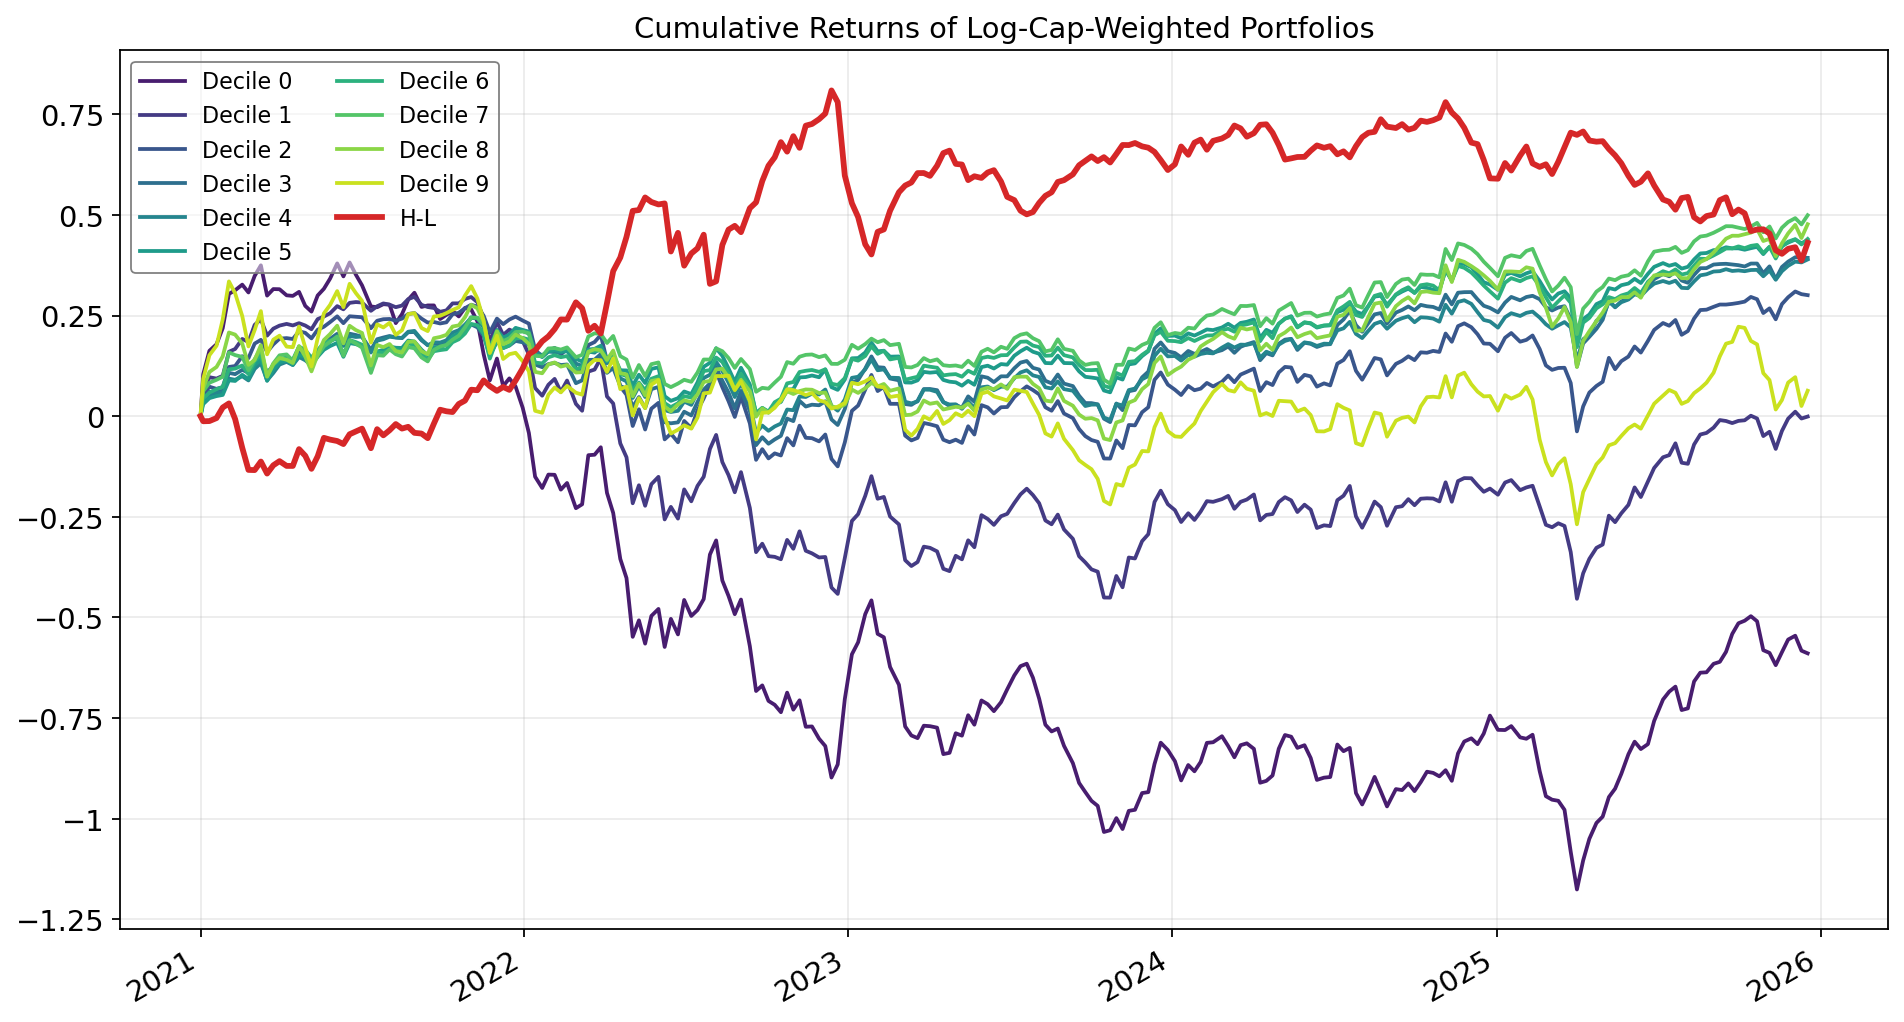

decile_spread_vw.png


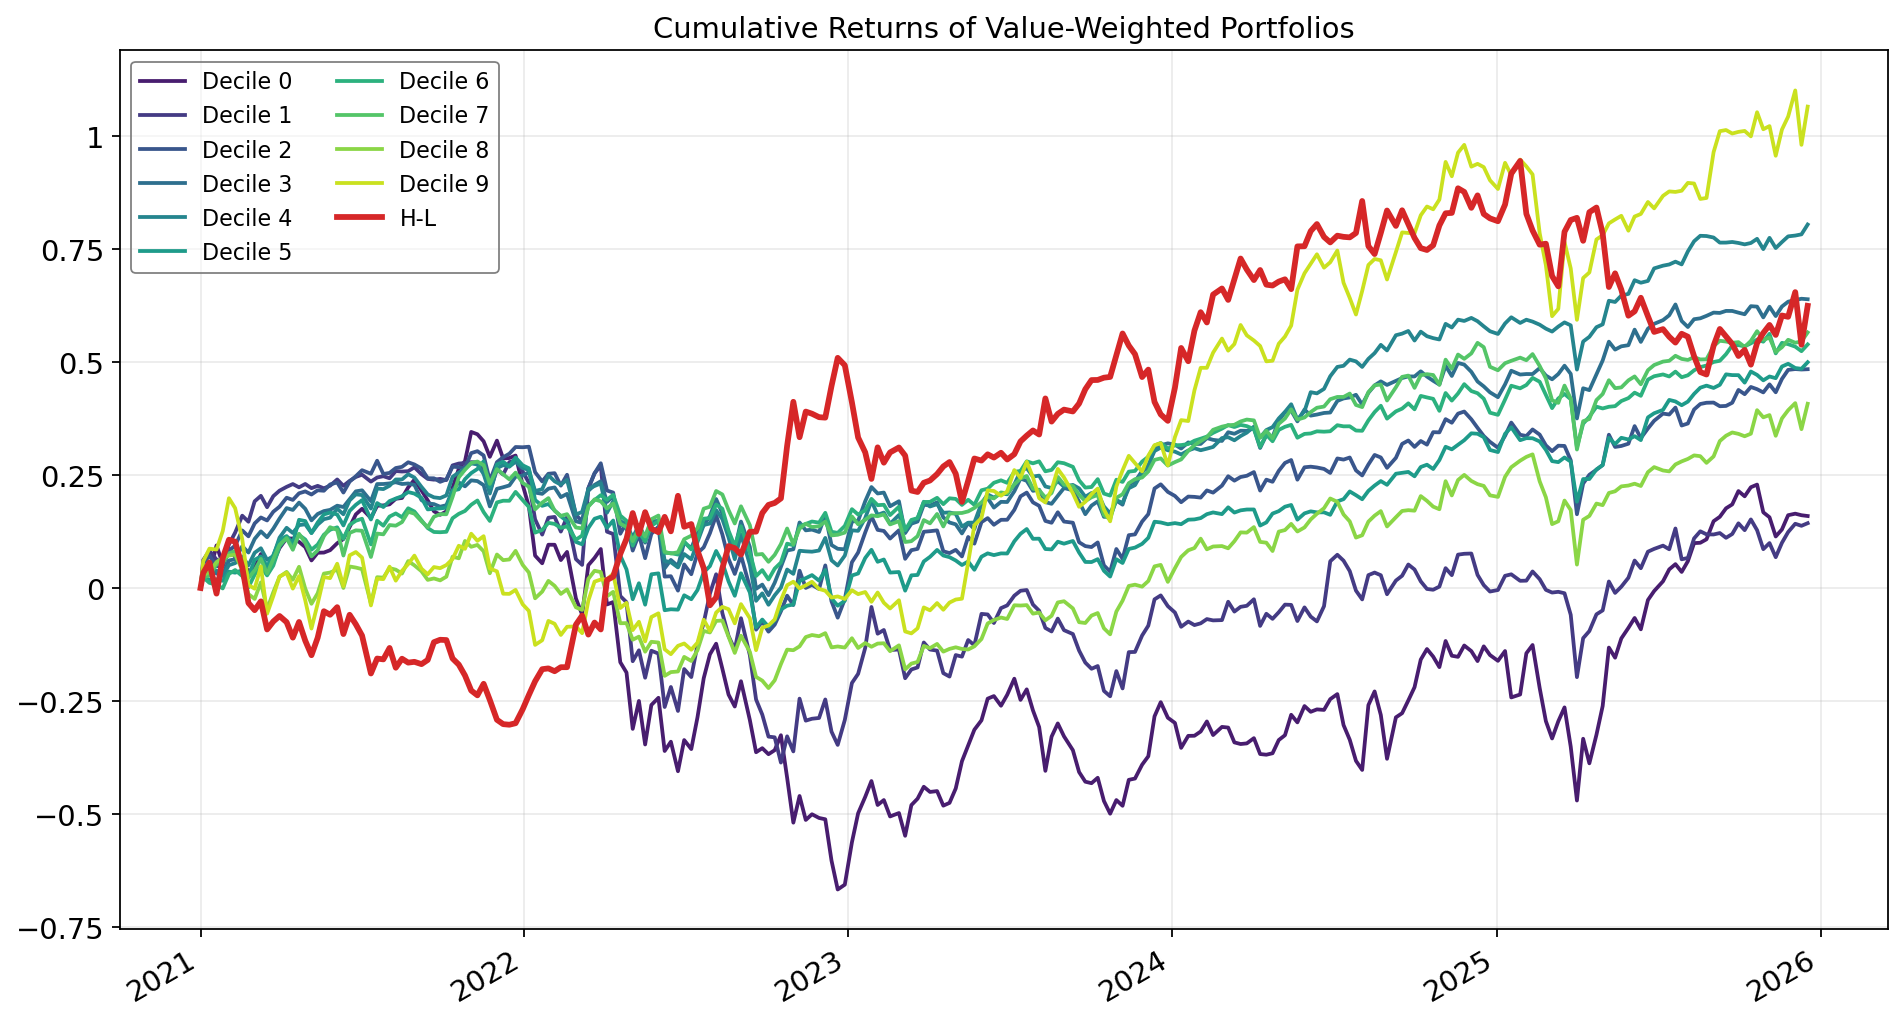

In [15]:
from IPython.display import Image, display

for path in result.outputs:
    if path.suffix == ".png":
        print(path.name)
        display(Image(str(path)))

## 7 读一次数据，扫一遍参数

四个阶段可以单独驱动，`InputBundle` 复用起来不用重读面板。

In [16]:
%%time
from stockportfoliotoolkit import Analyzer, InputProcessor, PortfolioEngine
from stockportfoliotoolkit.config import AnalyzerConfig, EngineConfig, InputConfig

bundle = InputProcessor(InputConfig.from_file(CONFIGS / "input.json")).run()
acfg = AnalyzerConfig.from_file(CONFIGS / "analyzer.json")

rows = []
for n in (5, 10, 20):
    ecfg = EngineConfig.from_file(CONFIGS / "engine.json")
    ecfg.n_buckets = n
    s = Analyzer(acfg).run(PortfolioEngine(ecfg).run(bundle)).summary
    hl = s[(s["bucket"] == "H-L") & (s["weight"] == "EW")].iloc[0]
    rows.append({"n_buckets": n, "ann_ret": hl["ann_ret"], "sharpe": hl["sharpe"], "turnover": hl["turnover"]})

pd.DataFrame(rows).round(4)

CPU times: user 21.1 s, sys: 7.47 s, total: 28.6 s
Wall time: 25.2 s


,n_buckets,ann_ret,sharpe,turnover
0,5,0.0866,0.4840,0.2265
1,10,0.0923,0.4288,0.2648
2,20,0.0185,0.0739,0.2893


## 8 加一个自己的权重器和指标

注册进去，然后在 JSON 里按名字引用。

In [ ]:
from stockportfoliotoolkit.analyzer import METRICS, Metric
from stockportfoliotoolkit.engine import WEIGHTERS, Weighter


if "sqrtvw" not in WEIGHTERS:

    @WEIGHTERS.register()
    class SqrtCapWeighter(Weighter):
        name = "sqrtvw"

        def weights(self, frame):
            w = np.sqrt(np.clip(np.nan_to_num(frame["cap"].to_numpy(float)), 0, None))
            return w / w.sum() if w.sum() > 0 else None


if "calmar" not in METRICS:

    @METRICS.register()
    class Calmar(Metric):
        name = "calmar"

        def compute(self, rets, ctx):
            dd = METRICS.get("max_drawdown")().compute(rets, ctx)
            return float(rets.mean() * ctx.periods_per_year / abs(dd)) if dd < 0 else float("nan")


WEIGHTERS.names(), METRICS.names()

(['ew', 'logvw', 'sqrtvw', 'vw'],
 ['ann_ret',
  'ann_vol',
  'calmar',
  'hit_rate',
  'max_drawdown',
  'sharpe',
  'total_equity'])

In [18]:
ecfg = EngineConfig.from_file(CONFIGS / "engine.json")
ecfg.weights = ["ew", "sqrtvw"]

acfg2 = AnalyzerConfig.from_file(CONFIGS / "analyzer.json")
acfg2.metrics = ["ann_ret", "sharpe", "max_drawdown", "calmar"]

s = Analyzer(acfg2).run(PortfolioEngine(ecfg).run(bundle)).summary
s[s["bucket"] == "H-L"].round(4)

,signal_model,bucket,weight,n_periods,ann_ret,sharpe,max_drawdown,calmar,turnover,ic_mean
10,MOM,H-L,EW,250,0.0923,0.4288,-0.4202,0.2197,0.2648,0.0291
21,MOM,H-L,SQRTVW,250,0.1485,0.6099,-0.2699,0.5501,0.2648,0.0291


## 9 配置写错了会怎样

In [19]:
from stockportfoliotoolkit.config import ConfigError, VisualizerConfig
from stockportfoliotoolkit.contracts import ContractError

for label, thunk in [
    ("拼错键名", lambda: EngineConfig.from_dict({"n_bucket": 10})),
    ("嵌套项写错", lambda: EngineConfig.from_dict({"long_short": {"enable": True}})),
    ("图例位置越界", lambda: VisualizerConfig.from_dict({"style": {"legend_loc": "center"}})),
    ("未注册的权重方案", lambda: PortfolioEngine(EngineConfig.from_dict({"weights": ["riskparity"]}))),
    (
        "映射到不存在的源列",
        lambda: InputProcessor(
            InputConfig.from_dict(
                {
                    **configs["input.json"],
                    "signals": [
                        {
                            "name": "MOM",
                            "path": str(SIGNAL_PATH),
                            "column_map": {"date": "date", "id": "id", "alpha": "signal_value"},
                        }
                    ],
                }
            )
        ).run(),
    ),
]:
    try:
        thunk()
    except (ConfigError, ContractError, KeyError) as exc:
        print(f"{label:12s} {type(exc).__name__}: {exc}\n")

拼错键名         ConfigError: engine: 未知配置项 ['n_bucket']；可用项为 ['forward_return', 'holding_days', 'include_references', 'long_short', 'min_names', 'n_buckets', 'reference_lag', 'weight_options', 'weights']

嵌套项写错        ConfigError: engine.long_short: 未知配置项 ['enable']；可用项为 ['enabled', 'label', 'reverse']

图例位置越界       ConfigError: visualizer.style.legend_loc: 图例位置只能取 ['upper left', 'upper right', 'lower left', 'lower right']，得到 'center'

未注册的权重方案     KeyError: "未知的 weighter: 'riskparity'；可用项为 ['ew', 'logvw', 'sqrtvw', 'vw']"

映射到不存在的源列    ContractError: signal_mom.feather: 源列 ['signal_value'] 不存在；实际列为 ['date', 'id', 'alpha', 'fwd_ret']



## 10 命令行

In [20]:
!spt run --config-dir {CONFIGS} --no-render

{
  "signals": {
    "MOM": {
      "rows": 1211662,
      "assets": 6786,
      "first": "2021-01-04",
      "last": "2025-12-24",
      "rows_on_calendar": 1211662,
      "alpha_na_rate": 0.0
    }
  },
  "prices": {
    "rows": 6574703,
    "assets": 6786,
    "first": "2021-01-04",
    "last": "2025-12-31"
  },
  "references": [],
  "calendar": {
    "periods": 251,
    "first": "2021-01-04",
    "last": "2025-12-24",
    "rebalance_freq": 5,
    "native_stride": 5,
    "applied_stride": 1
  }
}

=== headline metrics ===
signal_model bucket weight  n_periods  ann_ret  ann_vol  sharpe  max_drawdown  total_equity  hit_rate  turnover  ic_mean
         MOM    H-L     EW        250   0.0923   0.2153  0.4288       -0.4202        1.4060     0.572    0.2648   0.0291
         MOM    H-L  LOGVW        250   0.1117   0.2208  0.5059       -0.3448        1.5386     0.568    0.2648   0.0291
         MOM    H-L     VW        250   0.1714   0.3024  0.5670       -0.3767        1.8676     0.528    0

# 11 下一步计划
* 简化配置输入
* 目前只能生成一个 alpha 的组合，后续将支持多 alpha 组合和比较
* 丰富结果图表